In [25]:
import os

import matplotlib.pyplot as plt
#导包
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import mpl

os.chdir(r'D:\math1')
sns.set_style('darkgrid')
sns.set_palette('husl')

mpl.rcParams['font.sans-serif'] = ['SimHei']
#加载数据集
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')
flights = sns.load_dataset('flights')


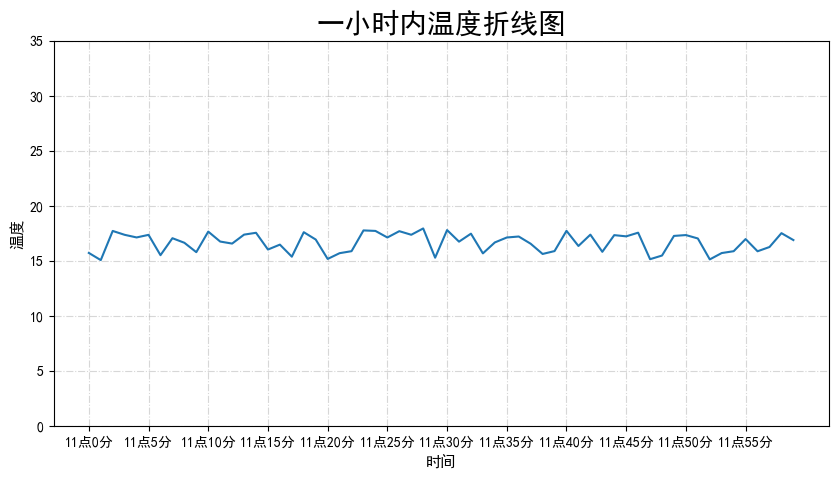

In [16]:
x = range(60)
y_shanghai = [np.random.uniform(15, 18) for i in x]
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(x, y_shanghai)
x_ticks_label = [f'11点{i}分' for i in x]
y_ticks = range(40)
plt.xticks(x[::5], x_ticks_label[::5])  #参1：x轴刻度值  参2：x轴刻度值对应的标签
plt.yticks(y_ticks[::5])
plt.grid(True, linestyle='-.', alpha=0.5)

plt.xlabel('时间', fontsize=11)  #添加x,y轴标签
plt.ylabel('温度', fontsize=11)

plt.title('一小时内温度折线图', fontsize=20)  #添加标题
plt.savefig('shanghai.png', dpi=100)

plt.show()

C:\Users\icyw\AppData\Local\Temp\ipykernel_5720\4293755804.py:3: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.scatterplot(


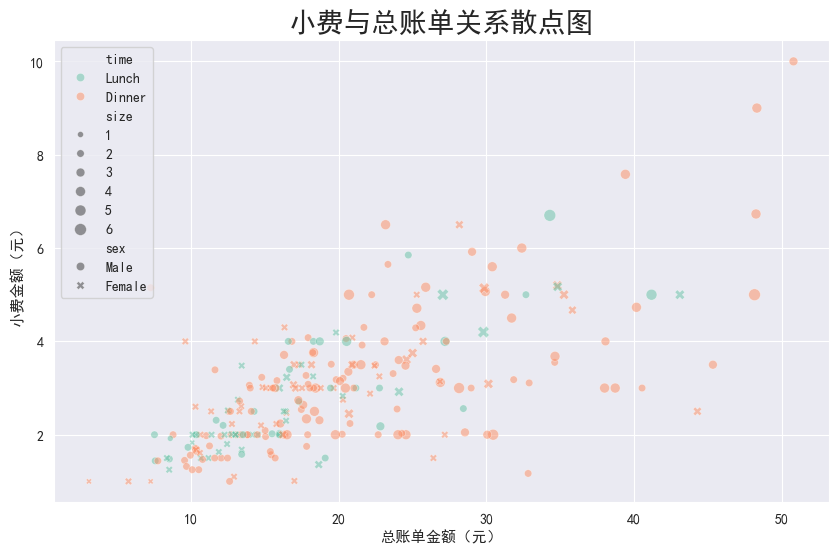

In [26]:
#散点图
plt.figure(figsize=(10, 6), dpi=100)
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    style='sex',
    alpha=0.5,
    palette=sns.color_palette('Set2')
)
plt.xlabel('总账单金额（元）', fontsize=11)
plt.ylabel('小费金额（元）', fontsize=11)
plt.title('小费与总账单关系散点图', fontsize=20)
plt.legend(loc=0)
plt.show()

C:\Users\icyw\AppData\Local\Temp\ipykernel_5720\1768694845.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


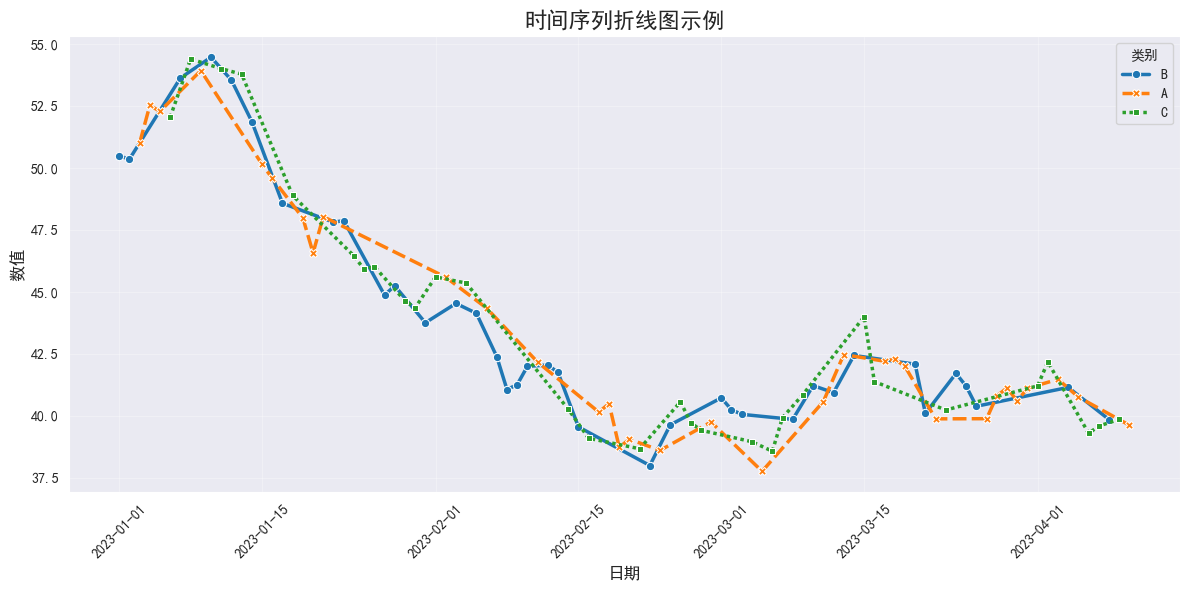

In [27]:
plt.figure(figsize=(12, 6))

# 准备时间序列数据示例
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=100, freq='D')
data = pd.DataFrame({
    'date': dates,
    'value_a': np.cumsum(np.random.randn(100)) + 50,
    'value_b': np.cumsum(np.random.randn(100)) + 30,
    'category': np.random.choice(['A', 'B', 'C'], 100)
})

# 创建折线图
sns.lineplot(
    data=data,
    x='date',
    y='value_a',
    hue='category',
    style='category',
    markers=True,
    linewidth=2.5,
    ci='sd',  # 显示标准差作为置信区间
    err_style='band',  # 置信区间显示为带状
    palette='tab10'
)

plt.title('时间序列折线图示例', fontsize=16, fontweight='bold')
plt.xlabel('日期', fontsize=12)
plt.ylabel('数值', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='类别')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

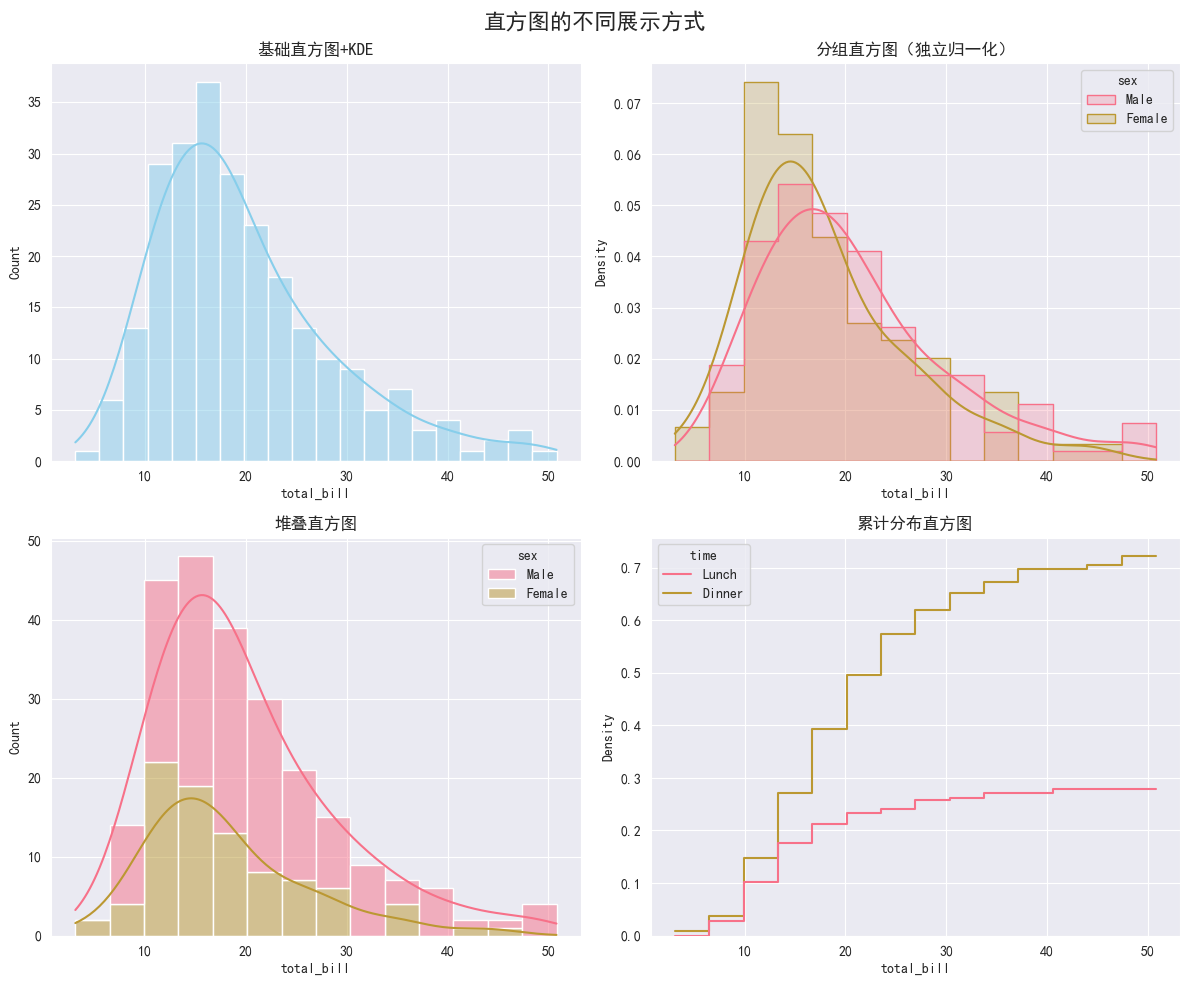

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 基础直方图
sns.histplot(
    data=tips,
    x="total_bill",
    kde=True,  # 叠加核密度估计
    bins=20,  # 分箱数量
    color='skyblue',
    ax=axes[0, 0]
)
axes[0, 0].set_title("基础直方图+KDE")

# 分组直方图
sns.histplot(
    data=tips,
    x="total_bill",
    hue="sex",  # 按性别分组
    kde=True,
    element="step",  # 阶梯样式
    stat="density",  # 显示密度而非计数
    common_norm=False,  # 各组独立归一化
    ax=axes[0, 1]
)
axes[0, 1].set_title("分组直方图（独立归一化）")

# 堆叠直方图
sns.histplot(
    data=tips,
    x="total_bill",
    hue="sex",
    multiple="stack",  # 堆叠显示
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("堆叠直方图")

# 累计分布直方图
sns.histplot(
    data=tips,
    x="total_bill",
    hue="time",
    cumulative=True,  # 累计分布
    element="step",
    fill=False,  # 不填充
    stat="density",
    ax=axes[1, 1]
)
axes[1, 1].set_title("累计分布直方图")

plt.suptitle("直方图的不同展示方式", fontsize=16, y=0.98)
plt.tight_layout()

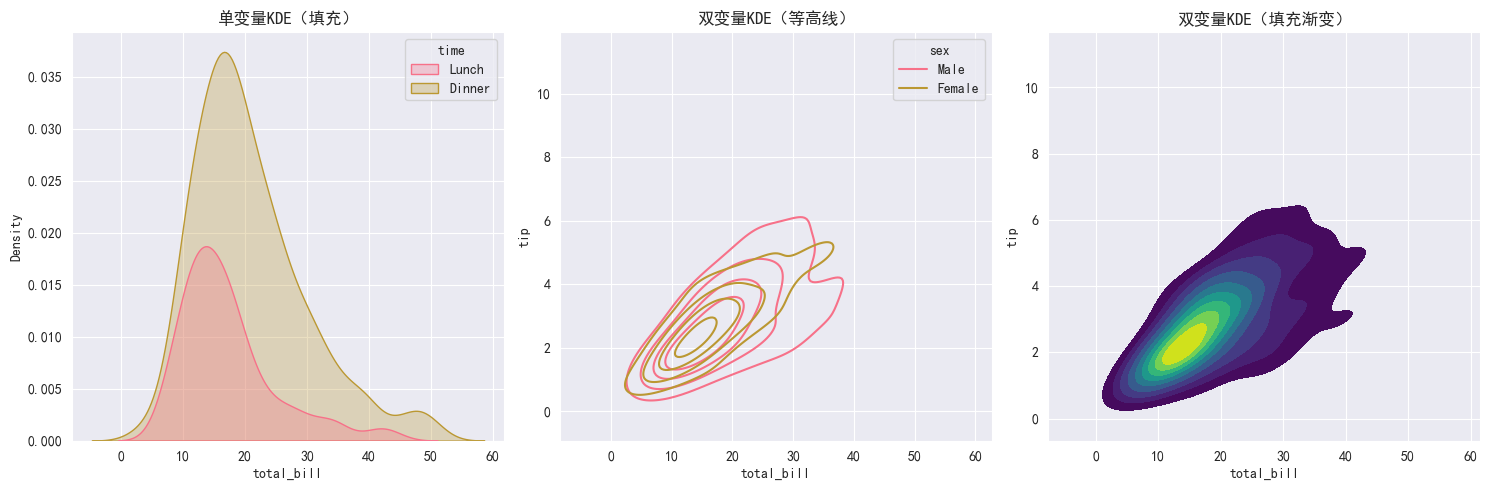

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 单变量KDE
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="time",  # 按时间分组
    fill=True,  # 填充颜色
    alpha=0.3,  # 透明度
    bw_adjust=0.8,  # 带宽调整（平滑程度）
    ax=axes[0]
)
axes[0].set_title("单变量KDE（填充）")

# 双变量KDE（等高线）
sns.kdeplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",  # 按性别分组
    levels=5,  # 等高线数量
    thresh=0.2,  # 阈值
    ax=axes[1]
)
axes[1].set_title("双变量KDE（等高线）")

# 双变量KDE（填充）
sns.kdeplot(
    data=tips,
    x="total_bill",
    y="tip",
    fill=True,  # 填充颜色
    cmap="viridis",  # 颜色映射
    thresh=0.1,
    ax=axes[2]
)
axes[2].set_title("双变量KDE（填充渐变）")

plt.tight_layout()

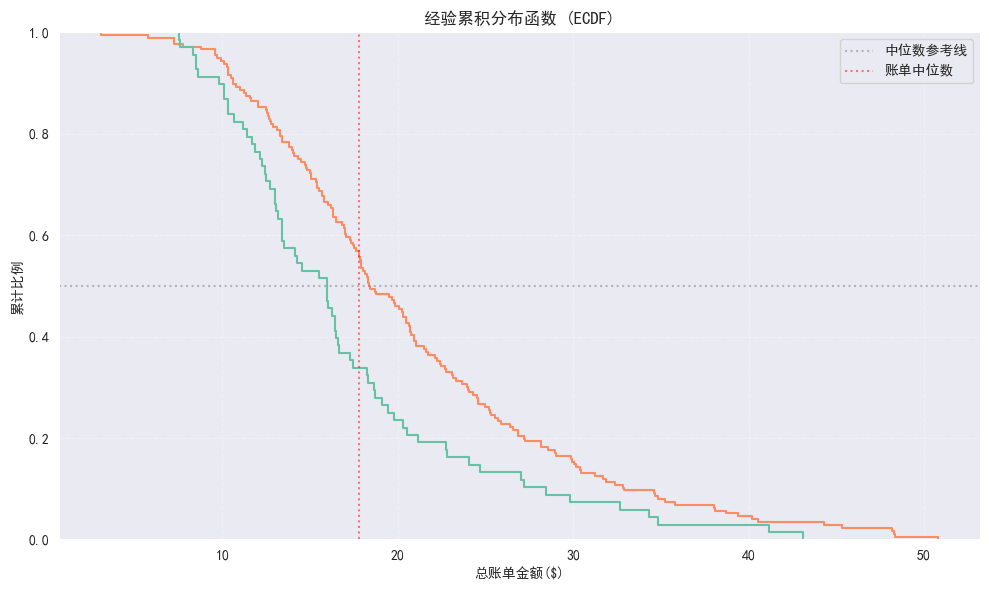

In [30]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(
    data=tips,
    x="total_bill",
    hue="time",  # 按时间分组
    stat="proportion",  # 显示比例
    complementary=True,  # 显示互补累积分布
    palette="Set2"
)

plt.title("经验累积分布函数 (ECDF)")
plt.xlabel("总账单金额($)")
plt.ylabel("累计比例")
plt.grid(True, alpha=0.3, linestyle='--')

# 添加参考线
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='中位数参考线')
plt.axvline(x=tips['total_bill'].median(), color='red', linestyle=':', alpha=0.5, label='账单中位数')

plt.legend()
plt.tight_layout()

TypeError: regplot() got an unexpected keyword argument 'linewidth'

D:\Anaconda_envs\envs\math1\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  func(*args, **kwargs)
D:\Anaconda_envs\envs\math1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


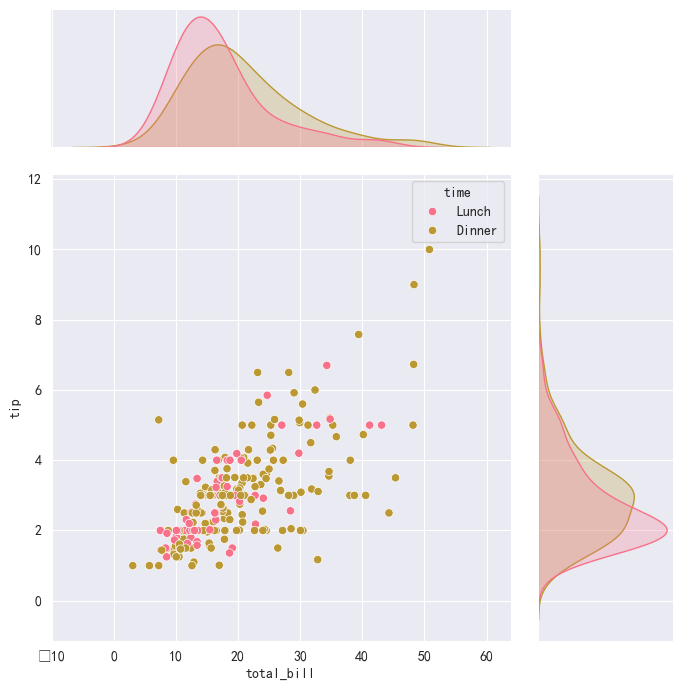

In [31]:
# 散点图+边缘直方图
g = sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="time",  # 按时间分组
    kind="scatter",  # 中心图类型：散点图
    marginal_kws={'common_norm': False},  # 边缘图参数
    height=7,  # 图形高度
    ratio=3,  # 中心图与边缘图的比例
    space=0.2  # 中心图与边缘图的间距
)

# 添加回归线
g.plot_joint(sns.regplot, scatter=False, color='red', linewidth=2)

# 添加相关性系数
from scipy import stats

corr, p_value = stats.pearsonr(tips['total_bill'], tips['tip'])
g.ax_joint.annotate(f'Pearson r = {corr:.3f}\np = {p_value:.4f}',
                    xy=(0.7, 0.9), xycoords='axes fraction',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

g.figure.suptitle("联合分布：总账单vs小费", y=1.02, fontsize=14)
g.set_axis_labels("总账单($)", "小费($)")

C:\Users\icyw\AppData\Local\Temp\ipykernel_5720\1232256435.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


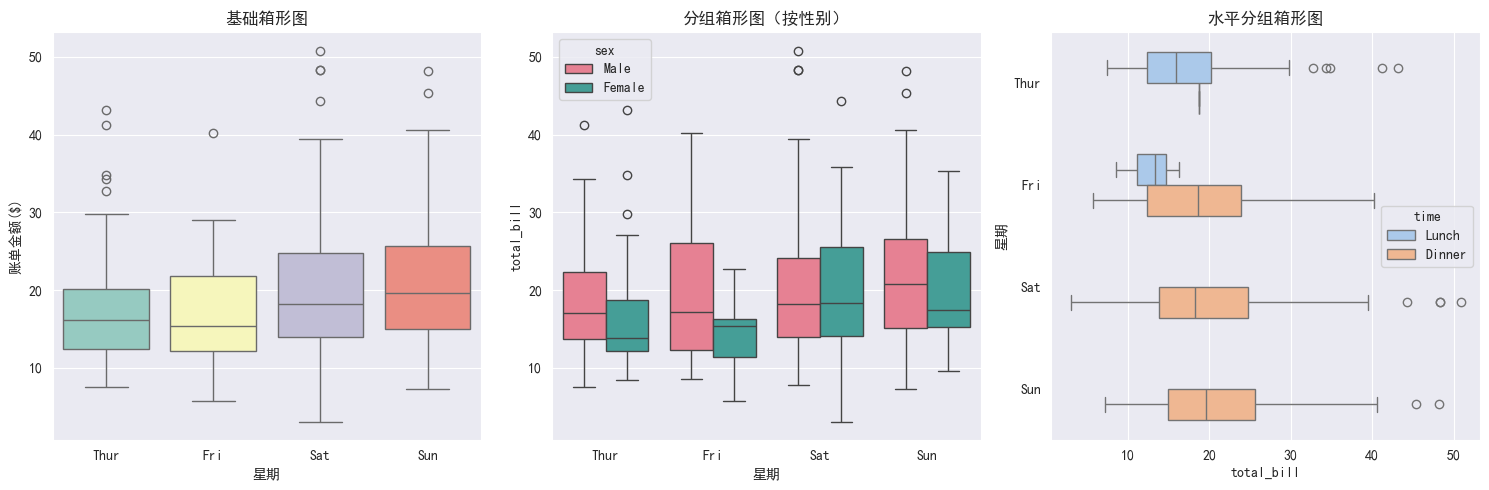

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 基础箱形图
sns.boxplot(
    data=tips,
    x="day",  # 分类变量
    y="total_bill",  # 数值变量
    palette="Set3",  # 颜色方案
    ax=axes[0]
)
axes[0].set_title("基础箱形图")
axes[0].set_xlabel("星期")
axes[0].set_ylabel("账单金额($)")

# 分组箱形图
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",  # 进一步分组
    palette="husl",
    ax=axes[1]
)
axes[1].set_title("分组箱形图（按性别）")
axes[1].set_xlabel("星期")

# 水平箱形图
sns.boxplot(
    data=tips,
    y="day",  # Y轴为分类变量
    x="total_bill",  # X轴为数值变量
    hue="time",  # 按时间分组
    palette="pastel",
    width=0.6,  # 箱体宽度
    dodge=True,  # 分组箱体并排显示
    ax=axes[2]
)
axes[2].set_title("水平分组箱形图")
axes[2].set_ylabel("星期")

# 添加中位数标注
for ax in axes:
    for i, artist in enumerate(ax.artists):
        # 获取中位数位置
        col = artist.get_facecolor()
        # 找到中位数线
        for j in range(6 * i, 6 * (i + 1)):
            line = ax.lines[j]
            if line.get_linestyle() == 'None':  # 中位数线
                x, y = line.get_data()
                median_val = x.mean()
                ax.text(i, median_val, f'{median_val:.1f}',
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()

C:\Users\icyw\AppData\Local\Temp\ipykernel_5720\3377089455.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\icyw\AppData\Local\Temp\ipykernel_5720\3377089455.py:3: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(
C:\Users\icyw\AppData\Local\Temp\ipykernel_5720\3377089455.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = tips.groupby(['day', 'sex'])['total_bill'].mean().reset_index()


AttributeError: module 'matplotlib.cm' has no attribute 'muted'

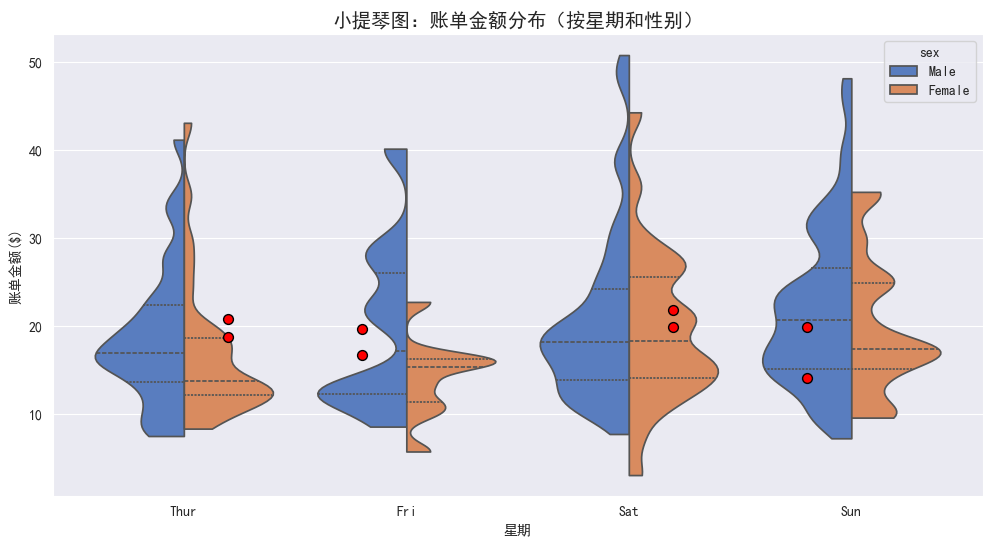

In [33]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",  # 按性别分组
    split=True,  # 分组共享一个小提琴
    inner="quartile",  # 内部显示四分位线
    scale="width",  # 宽度缩放方式
    palette="muted",  # 柔和的颜色
    bw=0.2,  # 带宽（平滑程度）
    cut=0  # 不修剪边缘
)

plt.title("小提琴图：账单金额分布（按星期和性别）", fontsize=14)
plt.xlabel("星期")
plt.ylabel("账单金额($)")

# 添加均值点
grouped = tips.groupby(['day', 'sex'])['total_bill'].mean().reset_index()
for i, (_, row) in enumerate(grouped.iterrows()):
    x_pos = i % 4 + (0.2 if row['sex'] == 'Male' else -0.2)
    plt.scatter(x_pos, row['total_bill'], color='red', s=50,
                zorder=5, edgecolor='black', label='均值' if i == 0 else "")

# 添加图例
from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=plt.cm.muted(0), alpha=0.6, label='Female'),
                   Patch(facecolor=plt.cm.muted(1), alpha=0.6, label='Male'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                              markersize=8, label='均值')]
plt.legend(handles=legend_elements, title='图例')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

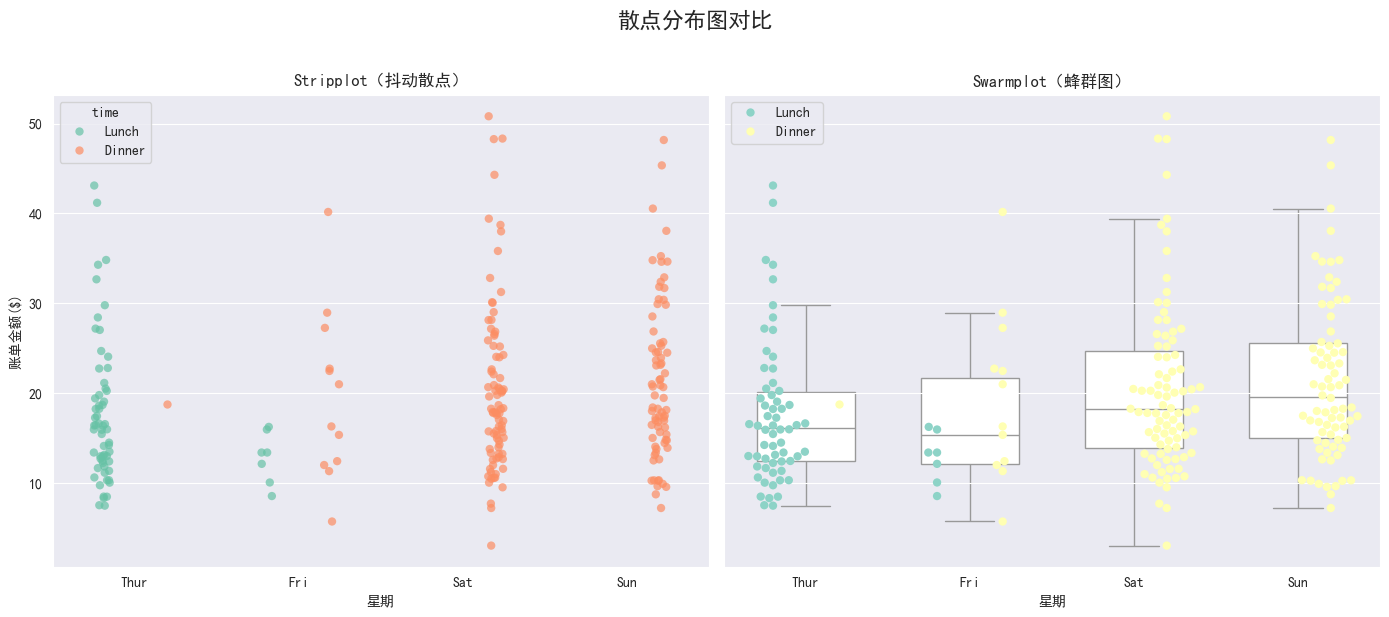

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Stripplot - 带抖动的散点
sns.stripplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="time",  # 按时间分组
    jitter=True,  # 添加抖动避免重叠
    dodge=True,  # 分组并排显示
    alpha=0.7,  # 透明度
    size=6,  # 点大小
    palette="Set2",
    ax=ax1
)
ax1.set_title("Stripplot（抖动散点）")
ax1.set_xlabel("星期")
ax1.set_ylabel("账单金额($)")

# Swarmplot - 蜂群图（避免重叠）
sns.swarmplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="time",
    dodge=True,
    palette="Set3",
    size=6,
    ax=ax2
)
ax2.set_title("Swarmplot（蜂群图）")
ax2.set_xlabel("星期")
ax2.set_ylabel("")

# 添加箱形图叠加
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    color="white",  # 白色背景
    width=0.6,  # 宽度
    fliersize=0,  # 不显示异常值点
    ax=ax2,
    zorder=0  # 置于底层
)

plt.suptitle("散点分布图对比", fontsize=16, y=1.02)
plt.tight_layout()

C:\Users\icyw\AppData\Local\Temp\ipykernel_5720\1413819307.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Figure size 1200x600 with 0 Axes>

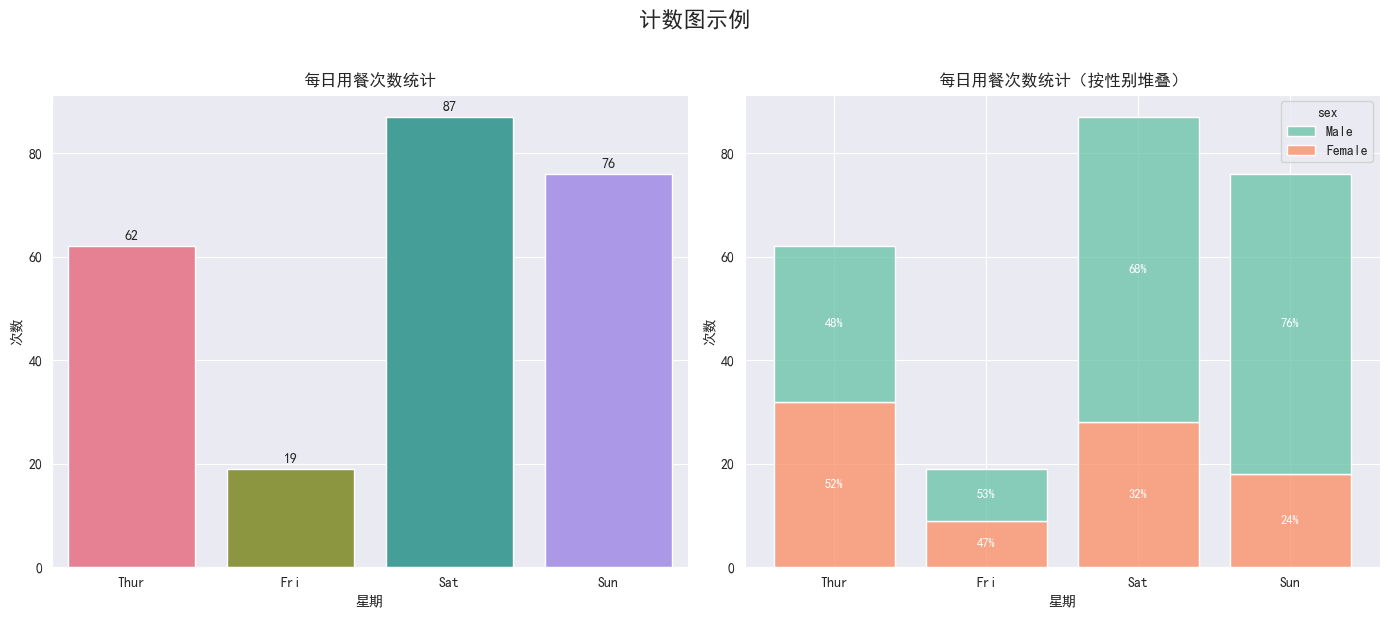

In [35]:
plt.figure(figsize=(12, 6))

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 基础计数图
sns.countplot(
    data=tips,
    x="day",
    palette="husl",  # 鲜艳颜色
    ax=ax1
)
ax1.set_title("每日用餐次数统计")
ax1.set_xlabel("星期")
ax1.set_ylabel("次数")

# 添加数值标签
for container in ax1.containers:
    ax1.bar_label(container, fontsize=10, padding=3)

# 分组堆叠计数图
sns.histplot(
    data=tips,
    x="day",
    hue="sex",  # 按性别分组
    multiple="stack",  # 堆叠显示
    shrink=0.8,  # 柱体宽度
    palette="Set2",
    ax=ax2
)
ax2.set_title("每日用餐次数统计（按性别堆叠）")
ax2.set_xlabel("星期")
ax2.set_ylabel("次数")

# 添加百分比标签
total_counts = tips['day'].value_counts().sort_index()
for i, container in enumerate(ax2.containers):
    for j, rect in enumerate(container.patches):
        height = rect.get_height()
        if height > 0:
            percentage = height / total_counts.iloc[j] * 100
            ax2.text(rect.get_x() + rect.get_width() / 2,
                     rect.get_y() + height / 2,
                     f'{percentage:.0f}%',
                     ha='center', va='center',
                     color='white', fontsize=9, fontweight='bold')

plt.suptitle("计数图示例", fontsize=16, y=1.02)
plt.tight_layout()

RuntimeError: `logistic=True` requires statsmodels, an optional dependency, to be installed.

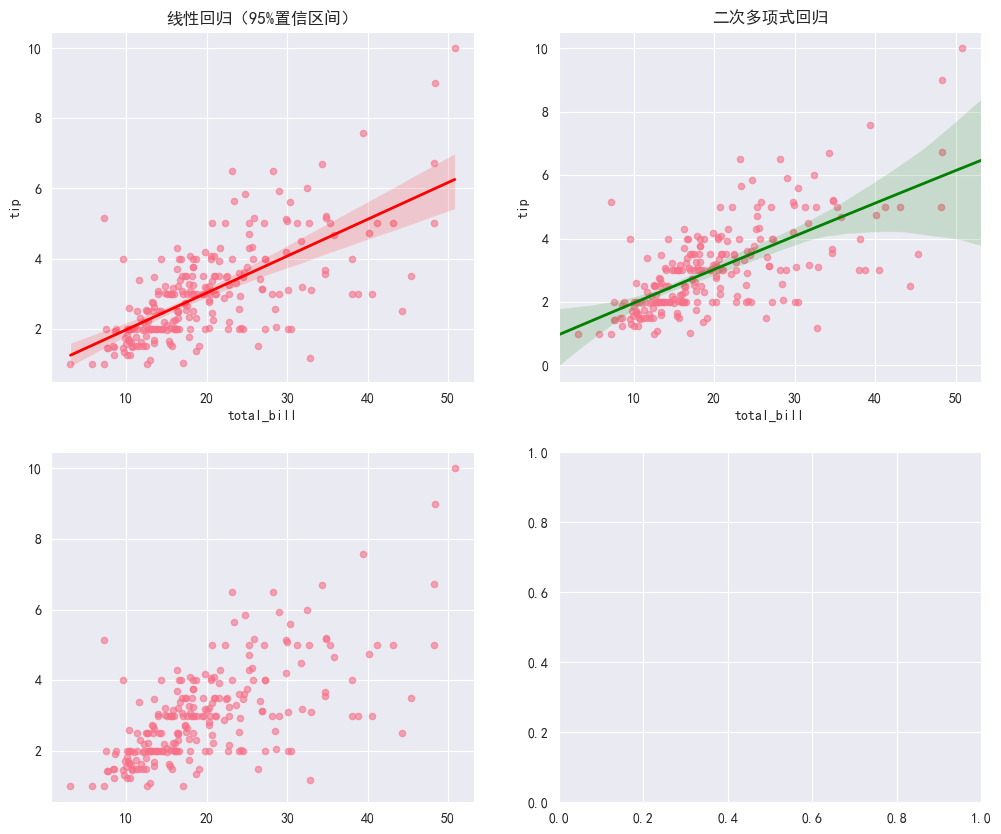

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 线性回归
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    scatter_kws={'s': 20, 'alpha': 0.6},  # 散点参数
    line_kws={'color': 'red', 'lw': 2},  # 回归线参数
    ci=95,  # 置信区间
    ax=axes[0, 0]
)
axes[0, 0].set_title("线性回归（95%置信区间）")

# 多项式回归
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    order=2,  # 二次多项式
    scatter_kws={'s': 20, 'alpha': 0.6},
    line_kws={'color': 'green', 'lw': 2},
    truncate=False,  # 不截断回归线
    ax=axes[0, 1]
)
axes[0, 1].set_title("二次多项式回归")

# 逻辑回归
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    logistic=True,  # 逻辑回归
    n_boot=500,  # 自助法次数
    scatter_kws={'s': 20, 'alpha': 0.6},
    line_kws={'color': 'purple', 'lw': 2},
    ax=axes[1, 0]
)
axes[1, 0].set_title("逻辑回归")

# 低平滑回归 (LOESS)
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    lowess=True,  # 局部加权回归
    scatter_kws={'s': 20, 'alpha': 0.6},
    line_kws={'color': 'orange', 'lw': 2},
    ax=axes[1, 1]
)
axes[1, 1].set_title("LOESS回归（局部加权）")

plt.suptitle("回归分析示例", fontsize=16, y=1.02)
plt.tight_layout()

TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given

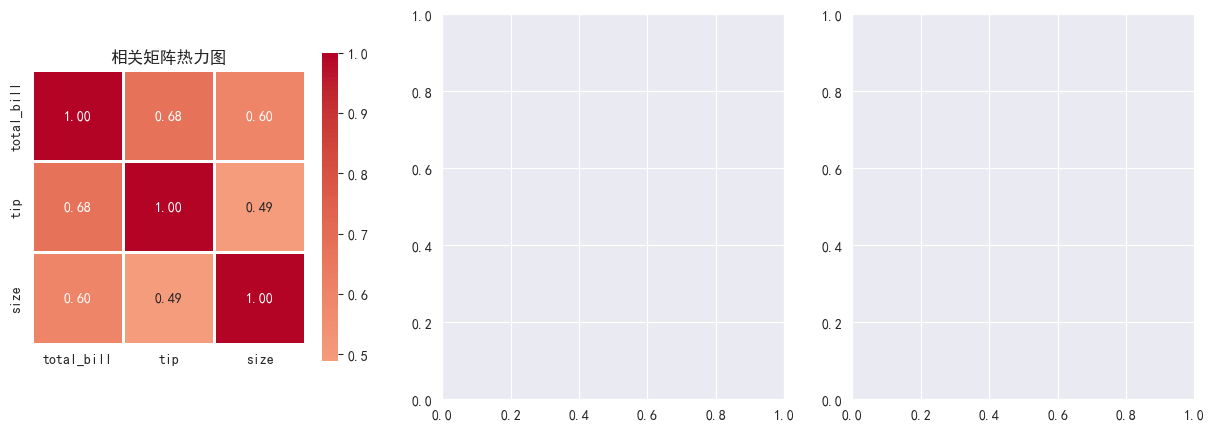

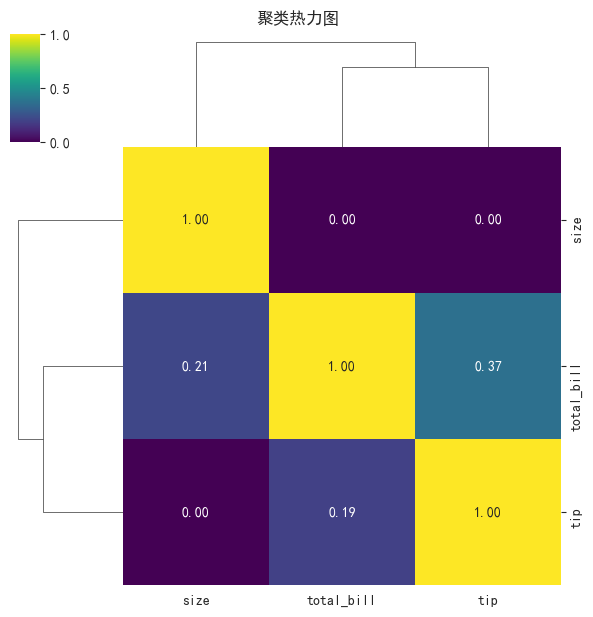

In [37]:
# 创建相关矩阵
corr_matrix = tips.select_dtypes(include=[np.number]).corr()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 基础热力图
sns.heatmap(
    corr_matrix,
    annot=True,  # 显示数值
    fmt=".2f",  # 数值格式
    cmap="coolwarm",  # 颜色映射
    center=0,  # 中心值
    square=True,  # 正方形单元格
    linewidths=1,  # 单元格边框
    cbar_kws={"shrink": 0.8},  # 颜色条设置
    ax=axes[0]
)
axes[0].set_title("相关矩阵热力图")

# 聚类热力图
sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    figsize=(6, 6),
    row_cluster=True,  # 行聚类
    col_cluster=True,  # 列聚类
    method='average',  # 聚类方法
    metric='euclidean',  # 距离度量
    standard_scale=1  # 标准化
)
plt.suptitle("聚类热力图", y=1.02)

# 创建时间序列数据
flights = sns.load_dataset("flights").pivot("month", "year", "passengers")

# 时间序列热力图
plt.figure(figsize=(12, 8))
sns.heatmap(
    flights,
    annot=True,
    fmt="d",  # 整数格式
    cmap="YlOrRd",  # 黄橙红渐变色
    linewidths=0.5,
    cbar_kws={'label': '乘客数量'}
)
plt.title("航班乘客数量热力图（1949-1960）", fontsize=14)
plt.xlabel("年份")
plt.ylabel("月份")
plt.xticks(rotation=0)
plt.tight_layout()

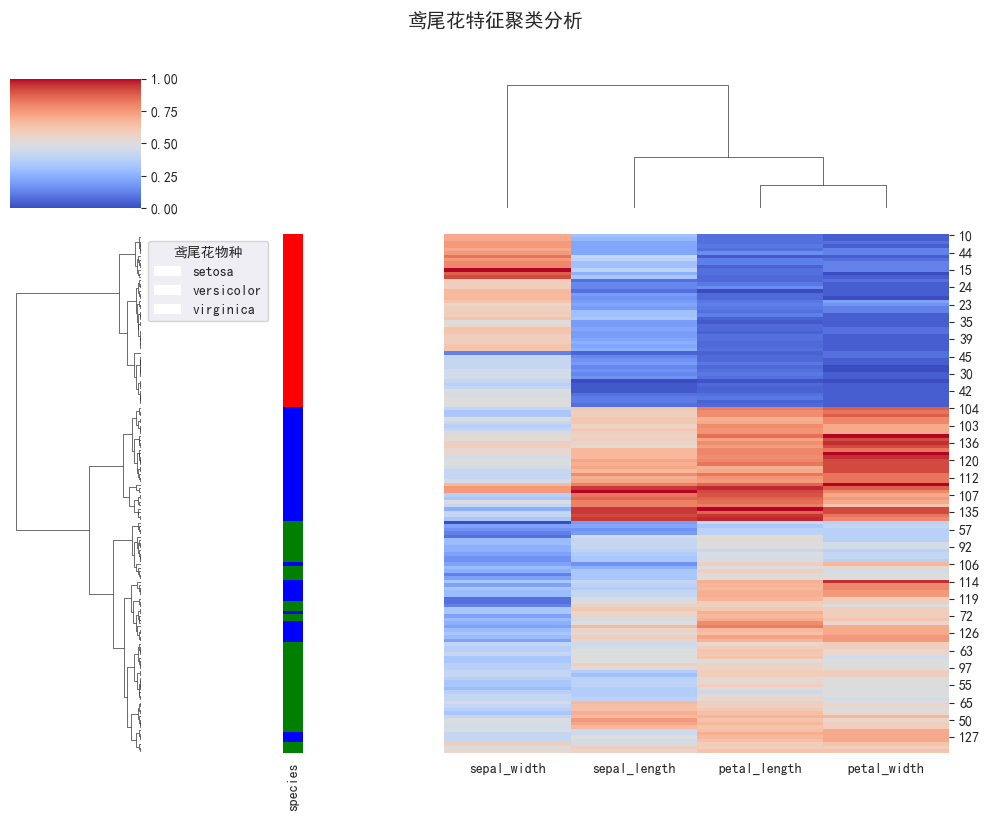

In [38]:
# 使用鸢尾花数据集
iris = sns.load_dataset("iris")
iris_numeric = iris.drop(columns='species')

# 创建聚类图
g = sns.clustermap(
    iris_numeric,
    method='ward',  # 聚类方法
    metric='euclidean',  # 距离度量
    standard_scale=1,  # 按列标准化
    cmap="coolwarm",  # 颜色映射
    figsize=(10, 8),  # 图形大小
    row_colors=pd.Series(iris['species']).map(
        {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
    ),  # 行颜色（按物种）
    dendrogram_ratio=0.2,  # 树状图比例
    colors_ratio=0.03,  # 颜色条比例
    cbar_pos=(0.02, 0.8, 0.05, 0.18)  # 颜色条位置
)

# 添加物种标签
for label in np.unique(iris['species']):
    g.ax_row_dendrogram.bar(0, 0, color='white', label=label, linewidth=0)

g.ax_row_dendrogram.legend(title="鸢尾花物种", loc="upper left",
                           bbox_to_anchor=(1, 1))

plt.suptitle("鸢尾花特征聚类分析", y=1.02, fontsize=14)
plt.tight_layout()